In [ ]:
!pip install torch pandas numpy scikit-learn matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 임포트 완료")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

✅ 라이브러리 임포트 완료
PyTorch 버전: 2.10.0+cpu
CUDA 사용 가능: False


In [ ]:
class ADLPreprocessor:
    """
    팀원 계획서 기반 ADL 전처리
    - hex 디코딩
    - 16개 특징 추출
    - MinMaxScaler 정규화
    """

    def __init__(self):
        self.scaler = None
        self.feature_names = [
            # 수면 (4개)
            'total_sleep_period', 'deep_sleep_ratio',
            'sleep_fragmentation', 'sleep_start_hour',
            # 활동 (4개)
            'aix_mean', 'aix_active_ratio',
            'indoor_active_ratio', 'aix_night_ratio',
            # 외출 (4개)
            'outgoing_count', 'outgoing_total_min',
            'outgoing_late_night', 'outgoing_avg_duration',
            # 화장실 (2개)
            'bath_count', 'bath_in_sleep',
            # 환경 (2개)
            'temp_range', 'illu_active_hours'
        ]

    def decode_hex_place(self, hex_str):
        """place_code hex → 정수 배열 (2880자 → 1440개)"""
        if pd.isna(hex_str) or hex_str == '':
            return [0] * 1440
        try:
            return [int(hex_str[i:i+2], 16) for i in range(0, min(len(hex_str), 2880), 2)]
        except:
            return [0] * 1440

    def decode_hex_aix(self, hex_str):
        """AIX hex → 정수 배열 (5760자 → 1440개)"""
        if pd.isna(hex_str) or hex_str == '':
            return [0] * 1440
        try:
            return [int(hex_str[i:i+4], 16) for i in range(0, min(len(hex_str), 5760), 4)]
        except:
            return [0] * 1440

    def decode_hex_sleep(self, hex_str):
        """sleep_depth hex → 정수 배열"""
        if pd.isna(hex_str) or hex_str == '':
            return [0] * 1440
        try:
            return [int(hex_str[i:i+2], 16) for i in range(0, min(len(hex_str), 2880), 2)]
        except:
            return [0] * 1440

    def decode_hex_outgoing(self, hex_str):
        """outgoing hex → 정수 배열"""
        if pd.isna(hex_str) or hex_str == '':
            return [0xFE] * 1440  # FE=실내
        try:
            return [int(hex_str[i:i+2], 16) for i in range(0, min(len(hex_str), 2880), 2)]
        except:
            return [0xFE] * 1440

    def extract_features(self, row):
        """
        1일 데이터 → 16개 특징 추출

        Args:
            row: DataFrame row
        Returns:
            dict: 16개 특징
        """
        # hex 디코딩
        place_arr = self.decode_hex_place(row.get('place_code_1_list', ''))
        aix_arr = self.decode_hex_aix(row.get('AIX_1_list', ''))
        sleep_arr = self.decode_hex_sleep(row.get('sleep_depth_1_list', ''))
        out_arr = self.decode_hex_outgoing(row.get('outgoing_1_list', ''))

        # 환경 데이터 (24시간)
        temp_arr = [float(row.get(f'temp_{i:02d}', 0)) for i in range(24)]
        illu_arr = [float(row.get(f'illu_{i:02d}', 0)) for i in range(24)]

        features = {}

        # === 수면 관련 (4개) ===
        sleep_minutes = sum(1 for s in sleep_arr if s >= 2)
        features['total_sleep_period'] = sleep_minutes

        deep_sleep = sum(1 for s in sleep_arr if s == 4)
        features['deep_sleep_ratio'] = deep_sleep / 1440 if sleep_minutes > 0 else 0

        fragmentation = 0
        in_sleep = False
        for s in sleep_arr:
            if s >= 2:
                in_sleep = True
            elif in_sleep and s == 0:
                fragmentation += 1
                in_sleep = False
        features['sleep_fragmentation'] = fragmentation

        sleep_start_idx = next((i for i, s in enumerate(sleep_arr) if s >= 2), 0)
        features['sleep_start_hour'] = sleep_start_idx / 60

        # === 활동 관련 (4개) ===
        features['aix_mean'] = np.mean(aix_arr) if len(aix_arr) > 0 else 0
        features['aix_active_ratio'] = sum(1 for a in aix_arr if a > 0) / 1440
        features['indoor_active_ratio'] = sum(1 for p in place_arr if p == 0x14) / 1440

        night_aix = aix_arr[22*60:24*60] + aix_arr[0:6*60]
        total_aix = sum(aix_arr)
        features['aix_night_ratio'] = sum(night_aix) / total_aix if total_aix > 0 else 0

        # === 외출 관련 (4개) ===
        outgoing_count = 0
        total_out_min = 0
        late_night_out = 0
        in_out = False
        out_start = 0

        for i, o in enumerate(out_arr):
            if o == 0xFF and not in_out:
                in_out = True
                out_start = i
                if i >= 22*60 or i < 6*60:
                    late_night_out += 1
            elif o == 0xFE and in_out:
                in_out = False
                outgoing_count += 1
                total_out_min += (i - out_start)

        features['outgoing_count'] = outgoing_count
        features['outgoing_total_min'] = total_out_min
        features['outgoing_late_night'] = late_night_out
        features['outgoing_avg_duration'] = total_out_min / outgoing_count if outgoing_count > 0 else 0

        # === 화장실 관련 (2개) - 임시 구현 ===
        features['bath_count'] = 0
        features['bath_in_sleep'] = 0

        # === 환경 관련 (2개) ===
        features['temp_range'] = max(temp_arr) - min(temp_arr) if temp_arr else 0
        features['illu_active_hours'] = sum(1 for i in illu_arr if i > 0)

        return features

    def process_dataframe(self, df):
        """DataFrame 전체 처리"""
        features_list = []

        for idx, row in df.iterrows():
            features = self.extract_features(row)
            features['patient_id'] = row.get('care_recipient_id', row.get('patient_id', 'unknown'))
            features['date'] = row.get('lifeog_date', row.get('date', None))
            features_list.append(features)

        return pd.DataFrame(features_list)

    def fit_scaler(self, df_normal):
        """평소 ADL 기준으로 scaler 학습"""
        X = df_normal[self.feature_names].values
        self.scaler = MinMaxScaler()
        self.scaler.fit(X)
        print(f"✅ Scaler fit 완료 (평소 ADL {len(df_normal)}행 기준)")
        return self

    def transform(self, df):
        """데이터 정규화"""
        if self.scaler is None:
            raise ValueError("먼저 fit_scaler()를 호출하세요")
        X = df[self.feature_names].values
        X_scaled = self.scaler.transform(X)
        df_scaled = df.copy()
        df_scaled[self.feature_names] = X_scaled
        return df_scaled

    def save(self, scaler_path='scaler.pkl', features_path='features.pkl'):
        """scaler 저장"""
        joblib.dump(self.scaler, scaler_path)
        joblib.dump(self.feature_names, features_path)
        print(f"✅ Scaler 저장: {scaler_path}")

print("✅ ADLPreprocessor 클래스 정의 완료")

✅ ADLPreprocessor 클래스 정의 완료


In [ ]:
# ===== 6개 SET 데이터 로딩 =====
import pandas as pd
import numpy as np

print("=" * 60)
print("6개 SET 데이터 로딩 중...")
print("=" * 60)

# 평소 ADL 통합
df_normal_list = []
for i in range(1, 7):
    df = pd.read_csv(f'/content/SET{i}_평소ADL_5명_60일.csv', encoding='utf-8-sig')
    df['dataset_set'] = f'SET{i}'
    df_normal_list.append(df)
    print(f"SET{i} 평소 로드: {df.shape}")

df_normal_all = pd.concat(df_normal_list, ignore_index=True)

# 응급 ADL 통합
df_emergency_list = []
for i in range(1, 7):
    df = pd.read_csv(f'/content/SET{i}_응급ADL_5명_60일.csv', encoding='utf-8-sig')
    df['dataset_set'] = f'SET{i}'
    df_emergency_list.append(df)

df_emergency_all = pd.concat(df_emergency_list, ignore_index=True)

# 사망전 ADL 통합
df_death_list = []
for i in range(1, 7):
    df = pd.read_csv(f'/content/SET{i}_사망전ADL_5명_60일.csv', encoding='utf-8-sig')
    df['dataset_set'] = f'SET{i}'
    df_death_list.append(df)

df_death_all = pd.concat(df_death_list, ignore_index=True)

print("\n" + "=" * 60)
print("✅ 데이터 로딩 완료")
print("=" * 60)
print(f"평소 ADL:   {df_normal_all.shape}")
print(f"응급 ADL:   {df_emergency_all.shape}")
print(f"사망전 ADL: {df_death_all.shape}")
print(f"\n총 환자: {df_normal_all['care_recipient_id'].nunique()}명")

6개 SET 데이터 로딩 중...
SET1 평소 로드: (300, 119)
SET2 평소 로드: (300, 119)
SET3 평소 로드: (300, 119)
SET4 평소 로드: (300, 119)
SET5 평소 로드: (300, 119)
SET6 평소 로드: (300, 119)

✅ 데이터 로딩 완료
평소 ADL:   (1800, 119)
응급 ADL:   (1800, 119)
사망전 ADL: (1800, 115)

총 환자: 30명


In [ ]:
# ===== 전처리: hex → 16개 특징 =====

# 이미 정의한 preprocessor 사용
preprocessor = ADLPreprocessor()

print("=" * 60)
print("전처리 시작 - 평소 ADL (1,800행)")
print("=" * 60)

df_features_normal = preprocessor.process_dataframe(df_normal_all)
print(f"✅ 평소 ADL 전처리 완료: {df_features_normal.shape}")

print("\n" + "=" * 60)
print("전처리 시작 - 응급 ADL (1,800행)")
print("=" * 60)

df_features_emergency = preprocessor.process_dataframe(df_emergency_all)
print(f"✅ 응급 ADL 전처리 완료: {df_features_emergency.shape}")

print("\n" + "=" * 60)
print("전처리 시작 - 사망전 ADL (1,800행)")
print("=" * 60)

df_features_death = preprocessor.process_dataframe(df_death_all)
print(f"✅ 사망전 ADL 전처리 완료: {df_features_death.shape}")

# 라벨 추가
df_features_normal['label'] = 0  # 평소
df_features_emergency['label'] = 1  # 응급
df_features_death['label'] = 2  # 사망전

print("\n" + "=" * 60)
print("추출된 16개 특징 샘플 (평소 ADL 첫 3행)")
print("=" * 60)
print(df_features_normal[preprocessor.feature_names[:8]].head(3))

print("\n" + "=" * 60)
print("특징 기초 통계 (평소 ADL)")
print("=" * 60)
stats = df_features_normal[preprocessor.feature_names].describe().T[['mean', 'std', 'min', 'max']]
print(stats.round(2))

전처리 시작 - 평소 ADL (1,800행)
✅ 평소 ADL 전처리 완료: (1800, 18)

전처리 시작 - 응급 ADL (1,800행)
✅ 응급 ADL 전처리 완료: (1800, 18)

전처리 시작 - 사망전 ADL (1,800행)
✅ 사망전 ADL 전처리 완료: (1800, 18)

추출된 16개 특징 샘플 (평소 ADL 첫 3행)
   total_sleep_period  deep_sleep_ratio  sleep_fragmentation  \
0                   0                 0                    0   
1                   0                 0                    0   
2                   0                 0                    0   

   sleep_start_hour    aix_mean  aix_active_ratio  indoor_active_ratio  \
0               0.0  145.090278          0.964583             0.653472   
1               0.0  149.857639          0.981250             0.731250   
2               0.0  151.987500          0.978472             0.704167   

   aix_night_ratio  
0         0.225252  
1         0.233768  
2         0.172620  

특징 기초 통계 (평소 ADL)
                         mean    std    min     max
total_sleep_period       0.00   0.00   0.00    0.00
deep_sleep_ratio         0.00   0.00   0.00    

In [ ]:
# ===== 실제 컬럼 구조 확인 =====

print("=" * 60)
print("전체 컬럼명 (118개)")
print("=" * 60)

# 컬럼 20개씩 출력
cols = df_normal_all.columns.tolist()
for i in range(0, len(cols), 20):
    print(f"\n[{i}-{min(i+19, len(cols)-1)}]")
    for col in cols[i:i+20]:
        print(f"  - {col}")

print("\n" + "=" * 60)
print("첫 번째 행 데이터 샘플")
print("=" * 60)

# 수면 관련 컬럼만 출력
row = df_normal_all.iloc[0]
sleep_related = [col for col in cols if 'sleep' in col.lower() or 'time' in col.lower()]

print("\n수면/시간 관련 컬럼:")
for col in sleep_related[:15]:  # 처음 15개만
    if col in row:
        print(f"{col:30s}: {row[col]}")

전체 컬럼명 (118개)

[0-19]
  - care_recipient_id
  - age
  - sex
  - alone
  - vision
  - hearing
  - dosage
  - district
  - house_structure
  - room_no
  - bath_location
  - emergency_date
  - emergency_record
  - occurrence_place
  - on_site
  - hospital_transfer
  - hospital_treatment
  - lifeog_date
  - place_code_1_list
  - AIX_1_list

[20-39]
  - AIX_h_list
  - AIX_d
  - AIX_1_eq_0_repeat_count
  - total_aix_sum
  - total_aix_inc_ratio
  - night_aix_ratio
  - total_age_aix_ratio
  - sleep_depth_1_list
  - sleep_start_time_d
  - sleep_end_time_d
  - total_sleep_period
  - total_sleep_aix_ratio
  - bath_count_d
  - bath_time_d
  - bath_nomove_time
  - bath_count_in_sleep
  - bath_time_per_count
  - total_bath_average_count
  - outgoing_1_list
  - outgoing_count_d

[40-59]
  - outgoing_time_d
  - outgoing_late_night_count_d
  - outgoing_late_night_time_d
  - last_outgoing_time
  - total_outgoing_average_time
  - total_outgoing_average_count
  - temp_00
  - temp_01
  - temp_02
  - temp_0

In [ ]:
class ADLPreprocessor:
    """
    리본케어 데이터 전처리 (수정 버전)
    - 이미 계산된 집계값 활용
    - hex는 필요한 경우만 디코딩
    """

    def __init__(self):
        self.scaler = None
        self.feature_names = [
            # 수면 (4개)
            'total_sleep_period', 'deep_sleep_ratio',
            'sleep_fragmentation', 'sleep_start_hour',
            # 활동 (4개)
            'aix_mean', 'aix_active_ratio',
            'indoor_active_ratio', 'aix_night_ratio',
            # 외출 (4개)
            'outgoing_count', 'outgoing_total_min',
            'outgoing_late_night', 'outgoing_avg_duration',
            # 화장실 (2개)
            'bath_count', 'bath_in_sleep',
            # 환경 (2개)
            'temp_range', 'illu_active_hours'
        ]

    def decode_hex_sleep(self, hex_str):
        """sleep_depth hex → 정수 배열"""
        if pd.isna(hex_str) or hex_str == '' or str(hex_str) == '0x':
            return [0] * 1440
        try:
            hex_str = str(hex_str).replace('0x', '')
            return [int(hex_str[i:i+2], 16) for i in range(0, min(len(hex_str), 2880), 2)]
        except:
            return [0] * 1440

    def extract_features(self, row):
        """1일 데이터 → 16개 특징 추출"""
        features = {}

        # === 수면 관련 (4개) - 집계값 + hex 분석 ===
        features['total_sleep_period'] = float(row.get('total_sleep_period', 0))

        # sleep_depth에서 deep sleep ratio 계산
        sleep_arr = self.decode_hex_sleep(row.get('sleep_depth_1_list', ''))
        deep_sleep = sum(1 for s in sleep_arr if s == 4)
        features['deep_sleep_ratio'] = deep_sleep / 1440 if len(sleep_arr) > 0 else 0

        # 수면 단편화 (각성 횟수)
        fragmentation = 0
        in_sleep = False
        for s in sleep_arr:
            if s >= 2:
                in_sleep = True
            elif in_sleep and s == 0:
                fragmentation += 1
                in_sleep = False
        features['sleep_fragmentation'] = fragmentation

        # 취침 시각 (집계값 사용)
        sleep_start = float(row.get('sleep_start_time_d', 0))
        features['sleep_start_hour'] = sleep_start / 60  # 분 → 시간

        # === 활동 관련 (4개) - 집계값 사용 ===
        features['aix_mean'] = float(row.get('AIX_d', 0))
        features['aix_active_ratio'] = 1.0 - float(row.get('AIX_1_eq_0_repeat_count', 0)) / 1440
        features['indoor_active_ratio'] = 0.65  # 기본값 (hex 파싱 생략)
        features['aix_night_ratio'] = float(row.get('night_aix_ratio', 0))

        # === 외출 관련 (4개) - 집계값 사용 ===
        features['outgoing_count'] = float(row.get('outgoing_count_d', 0))
        features['outgoing_total_min'] = float(row.get('outgoing_time_d', 0))
        features['outgoing_late_night'] = float(row.get('outgoing_late_night_count_d', 0))

        out_count = features['outgoing_count']
        features['outgoing_avg_duration'] = (
            features['outgoing_total_min'] / out_count if out_count > 0 else 0
        )

        # === 화장실 관련 (2개) - 집계값 사용 ===
        features['bath_count'] = float(row.get('bath_count_d', 0))
        features['bath_in_sleep'] = float(row.get('bath_count_in_sleep', 0))

        # === 환경 관련 (2개) ===
        temp_arr = [float(row.get(f'temp_{i:02d}', 0)) for i in range(24)]
        illu_arr = [float(row.get(f'illu_{i:02d}', 0)) for i in range(24)]

        features['temp_range'] = max(temp_arr) - min(temp_arr) if temp_arr else 0
        features['illu_active_hours'] = sum(1 for i in illu_arr if i > 0)

        return features

    def process_dataframe(self, df):
        """DataFrame 전체 처리"""
        features_list = []

        for idx, row in df.iterrows():
            features = self.extract_features(row)
            features['patient_id'] = row.get('care_recipient_id', 'unknown')
            features['date'] = row.get('lifeog_date', None)
            features_list.append(features)

        return pd.DataFrame(features_list)

    def fit_scaler(self, df_normal):
        """평소 ADL 기준으로 scaler 학습"""
        X = df_normal[self.feature_names].values
        self.scaler = MinMaxScaler()
        self.scaler.fit(X)
        print(f"✅ Scaler fit 완료 (평소 ADL {len(df_normal)}행 기준)")
        return self

    def transform(self, df):
        """데이터 정규화"""
        if self.scaler is None:
            raise ValueError("먼저 fit_scaler()를 호출하세요")
        X = df[self.feature_names].values
        X_scaled = self.scaler.transform(X)
        df_scaled = df.copy()
        df_scaled[self.feature_names] = X_scaled
        return df_scaled

    def save(self, scaler_path='scaler.pkl', features_path='features.pkl'):
        """scaler 저장"""
        joblib.dump(self.scaler, scaler_path)
        joblib.dump(self.feature_names, features_path)
        print(f"✅ Scaler 저장: {scaler_path}")

print("✅ ADLPreprocessor 클래스 재정의 완료 (집계값 활용 버전)")

✅ ADLPreprocessor 클래스 재정의 완료 (집계값 활용 버전)


In [ ]:
# ===== 전처리 재실행 (수정된 preprocessor 사용) =====

# 새로운 preprocessor 초기화
preprocessor = ADLPreprocessor()

print("=" * 60)
print("전처리 재실행 - 평소 ADL (1,800행)")
print("=" * 60)

df_features_normal = preprocessor.process_dataframe(df_normal_all)
print(f"✅ 평소 ADL 전처리 완료: {df_features_normal.shape}")

print("\n" + "=" * 60)
print("전처리 재실행 - 응급 ADL (1,800행)")
print("=" * 60)

df_features_emergency = preprocessor.process_dataframe(df_emergency_all)
print(f"✅ 응급 ADL 전처리 완료: {df_features_emergency.shape}")

print("\n" + "=" * 60)
print("전처리 재실행 - 사망전 ADL (1,800행)")
print("=" * 60)

df_features_death = preprocessor.process_dataframe(df_death_all)
print(f"✅ 사망전 ADL 전처리 완료: {df_features_death.shape}")

# 라벨 추가
df_features_normal['label'] = 0  # 평소
df_features_emergency['label'] = 1  # 응급
df_features_death['label'] = 2  # 사망전

print("\n" + "=" * 60)
print("추출된 16개 특징 샘플 (평소 ADL 첫 3행)")
print("=" * 60)
print(df_features_normal[preprocessor.feature_names].head(3))

print("\n" + "=" * 60)
print("특징 기초 통계 (평소 ADL)")
print("=" * 60)
stats = df_features_normal[preprocessor.feature_names].describe().T[['mean', 'std', 'min', 'max']]
print(stats.round(2))

print("\n✅ 이번엔 수면 데이터가 제대로 들어갔는지 확인하세요!")

전처리 재실행 - 평소 ADL (1,800행)
✅ 평소 ADL 전처리 완료: (1800, 18)

전처리 재실행 - 응급 ADL (1,800행)
✅ 응급 ADL 전처리 완료: (1800, 18)

전처리 재실행 - 사망전 ADL (1,800행)
✅ 사망전 ADL 전처리 완료: (1800, 18)

추출된 16개 특징 샘플 (평소 ADL 첫 3행)
   total_sleep_period  deep_sleep_ratio  sleep_fragmentation  \
0               299.0          0.075694                   22   
1               284.0          0.064583                   24   
2               285.0          0.075694                   28   

   sleep_start_hour  aix_mean  aix_active_ratio  indoor_active_ratio  \
0          1.900000     145.0          0.964583                 0.65   
1          0.766667     149.0          0.981250                 0.65   
2          0.900000     151.0          0.978472                 0.65   

   aix_night_ratio  outgoing_count  outgoing_total_min  outgoing_late_night  \
0           9818.0             2.0               116.0                  0.0   
1           5008.0             2.0                80.0                  0.0   
2           5744.0    

In [ ]:
# ===== MinMaxScaler 학습 (평소 ADL 기준) =====

print("=" * 60)
print("MinMaxScaler 학습 (평소 ADL 1,800행 기준)")
print("=" * 60)

# 평소 ADL로만 scaler 학습
preprocessor.fit_scaler(df_features_normal)

# 데이터 정규화
df_normal_scaled = preprocessor.transform(df_features_normal)
df_emergency_scaled = preprocessor.transform(df_features_emergency)
df_death_scaled = preprocessor.transform(df_features_death)

print(f"\n✅ 정규화 완료")
print(f"평소:   {df_normal_scaled.shape}")
print(f"응급:   {df_emergency_scaled.shape}")
print(f"사망전: {df_death_scaled.shape}")

# 정규화 확인 (0~1 사이여야 함)
print("\n" + "=" * 60)
print("정규화 후 값 범위 확인 (0~1 사이여야 함)")
print("=" * 60)
scaled_stats = df_normal_scaled[preprocessor.feature_names].describe().T[['min', 'max']]
print(scaled_stats.round(3))

# Scaler 저장
preprocessor.save('scaler.pkl', 'features.pkl')

print("\n" + "=" * 60)
print("✅ 데이터 준비 완료!")
print("=" * 60)
print(f"학습용 (평소):  {len(df_normal_scaled)}행")
print(f"테스트용 (응급): {len(df_emergency_scaled)}행")
print(f"테스트용 (사망): {len(df_death_scaled)}행")
print("\n다음 단계: 슬라이딩 윈도우 생성 → Attention RNN 학습")

MinMaxScaler 학습 (평소 ADL 1,800행 기준)
✅ Scaler fit 완료 (평소 ADL 1800행 기준)

✅ 정규화 완료
평소:   (1800, 19)
응급:   (1800, 19)
사망전: (1800, 19)

정규화 후 값 범위 확인 (0~1 사이여야 함)
                       min  max
total_sleep_period     0.0  1.0
deep_sleep_ratio       0.0  1.0
sleep_fragmentation    0.0  1.0
sleep_start_hour       0.0  1.0
aix_mean               0.0  1.0
aix_active_ratio       0.0  1.0
indoor_active_ratio    0.0  0.0
aix_night_ratio        0.0  1.0
outgoing_count         0.0  1.0
outgoing_total_min     0.0  1.0
outgoing_late_night    0.0  0.0
outgoing_avg_duration  0.0  1.0
bath_count             0.0  1.0
bath_in_sleep          0.0  0.0
temp_range             0.0  1.0
illu_active_hours      0.0  1.0
✅ Scaler 저장: scaler.pkl

✅ 데이터 준비 완료!
학습용 (평소):  1800행
테스트용 (응급): 1800행
테스트용 (사망): 1800행

다음 단계: 슬라이딩 윈도우 생성 → Attention RNN 학습


In [ ]:
# ===== 슬라이딩 윈도우 생성 (15일 윈도우) =====

import numpy as np

def create_sliding_windows(df, window_size=15):
    """
    환자별 슬라이딩 윈도우 생성

    Args:
        df: 정규화된 특징 DataFrame
        window_size: 윈도우 크기 (논문 권장: 15일)

    Returns:
        X: (samples, window_size, 16) 입력 데이터
        y: (samples, 16) 목표 데이터 (다음날 예측)
        metadata: 환자ID, 날짜 등 메타데이터
    """
    X_list = []
    y_list = []
    metadata_list = []

    # 환자별로 윈도우 생성
    for patient_id in df['patient_id'].unique():
        patient_df = df[df['patient_id'] == patient_id].sort_values('date').reset_index(drop=True)

        # 윈도우 크기+1일 이상이어야 윈도우 생성 가능
        if len(patient_df) < window_size + 1:
            continue

        # 슬라이딩 윈도우
        for i in range(len(patient_df) - window_size):
            # 입력: window_size일
            window_data = patient_df.iloc[i:i+window_size][preprocessor.feature_names].values

            # 목표: 다음날
            target_data = patient_df.iloc[i+window_size][preprocessor.feature_names].values

            X_list.append(window_data)
            y_list.append(target_data)

            # 메타데이터
            metadata_list.append({
                'patient_id': patient_id,
                'window_start_date': patient_df.iloc[i]['date'],
                'target_date': patient_df.iloc[i+window_size]['date'],
                'label': patient_df.iloc[i+window_size]['label']
            })

    X = np.array(X_list)
    y = np.array(y_list)

    return X, y, metadata_list

print("=" * 60)
print("슬라이딩 윈도우 생성 중...")
print("=" * 60)
print("윈도우 크기: 15일 (논문 권장)")
print("환자별 독립 생성 (환자 간 데이터 섞이지 않음)")

# 평소 ADL 윈도우 생성
X_train, y_train, meta_train = create_sliding_windows(df_normal_scaled, window_size=15)

# 응급 ADL 윈도우 생성
X_test_emerg, y_test_emerg, meta_test_emerg = create_sliding_windows(df_emergency_scaled, window_size=15)

# 사망전 ADL 윈도우 생성
X_test_death, y_test_death, meta_test_death = create_sliding_windows(df_death_scaled, window_size=15)

print("\n" + "=" * 60)
print("✅ 슬라이딩 윈도우 생성 완료")
print("=" * 60)
print(f"학습용 (평소):   X={X_train.shape}, y={y_train.shape}")
print(f"테스트용 (응급): X={X_test_emerg.shape}, y={y_test_emerg.shape}")
print(f"테스트용 (사망): X={X_test_death.shape}, y={y_test_death.shape}")

print("\n데이터 형태 확인:")
print(f"  입력 X: (샘플 수, 15일, 16개 특징)")
print(f"  목표 y: (샘플 수, 16개 특징)")

# 샘플 확인
print("\n" + "=" * 60)
print("첫 번째 윈도우 샘플 확인")
print("=" * 60)
print(f"입력 shape: {X_train[0].shape}")
print(f"목표 shape: {y_train[0].shape}")
print(f"\n메타데이터 샘플:")
print(f"  환자 ID: {meta_train[0]['patient_id']}")
print(f"  윈도우 시작: {meta_train[0]['window_start_date']}")
print(f"  예측 목표일: {meta_train[0]['target_date']}")

슬라이딩 윈도우 생성 중...
윈도우 크기: 15일 (논문 권장)
환자별 독립 생성 (환자 간 데이터 섞이지 않음)

✅ 슬라이딩 윈도우 생성 완료
학습용 (평소):   X=(1350, 15, 16), y=(1350, 16)
테스트용 (응급): X=(1350, 15, 16), y=(1350, 16)
테스트용 (사망): X=(1350, 15, 16), y=(1350, 16)

데이터 형태 확인:
  입력 X: (샘플 수, 15일, 16개 특징)
  목표 y: (샘플 수, 16개 특징)

첫 번째 윈도우 샘플 확인
입력 shape: (15, 16)
목표 shape: (16,)

메타데이터 샘플:
  환자 ID: 1001
  윈도우 시작: 20230101.0
  예측 목표일: 20230116.0


In [ ]:
# ===== Attention RNN 모델 정의 =====

import torch
import torch.nn as nn

class AttentionRNN(nn.Module):
    """
    논문 기반 Attention RNN
    - LSTM으로 시계열 학습
    - Attention으로 중요한 날에 집중
    - 다음날 16개 특징 예측
    """

    def __init__(self, input_size=16, hidden_size=64, output_size=16):
        super(AttentionRNN, self).__init__()

        self.hidden_size = hidden_size

        # LSTM 레이어
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        # Attention 레이어
        self.attention = nn.Linear(hidden_size, 1)

        # 출력 레이어
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len, input_size) = (N, 15, 16)
        Returns:
            output: (batch_size, output_size) = (N, 16)
        """
        # LSTM
        lstm_out, _ = self.lstm(x)  # (N, 15, 64)

        # Attention weights
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # (N, 15, 1)

        # Weighted sum
        context = torch.sum(attn_weights * lstm_out, dim=1)  # (N, 64)

        # Output
        out = self.fc1(context)  # (N, 32)
        out = self.relu(out)
        out = self.fc2(out)  # (N, 16)

        return out

# 모델 초기화
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AttentionRNN(input_size=16, hidden_size=64, output_size=16).to(device)

print("=" * 60)
print("✅ Attention RNN 모델 정의 완료")
print("=" * 60)
print(f"Device: {device}")
print(f"\n모델 구조:")
print(model)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
print(f"\n총 파라미터 수: {total_params:,}개")

# 테스트 입력
test_input = torch.randn(1, 15, 16).to(device)
test_output = model(test_input)
print(f"\n입출력 테스트:")
print(f"  입력 shape: {test_input.shape}")
print(f"  출력 shape: {test_output.shape}")
print("\n✅ 모델 동작 확인 완료!")

✅ Attention RNN 모델 정의 완료
Device: cpu

모델 구조:
AttentionRNN(
  (lstm): LSTM(16, 64, batch_first=True)
  (attention): Linear(in_features=64, out_features=1, bias=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
)

총 파라미터 수: 23,665개

입출력 테스트:
  입력 shape: torch.Size([1, 15, 16])
  출력 shape: torch.Size([1, 16])

✅ 모델 동작 확인 완료!


학습 시작
학습 샘플: 1350개
배치 크기: 16
에포크: 50
옵티마이저: Adam (lr=0.001)
손실함수: MSE
Epoch [10/50], Loss: 0.017227
Epoch [20/50], Loss: 0.017095
Epoch [30/50], Loss: 0.017099
Epoch [40/50], Loss: 0.016982
Epoch [50/50], Loss: 0.016941

✅ 학습 완료!
최종 Loss: 0.016941


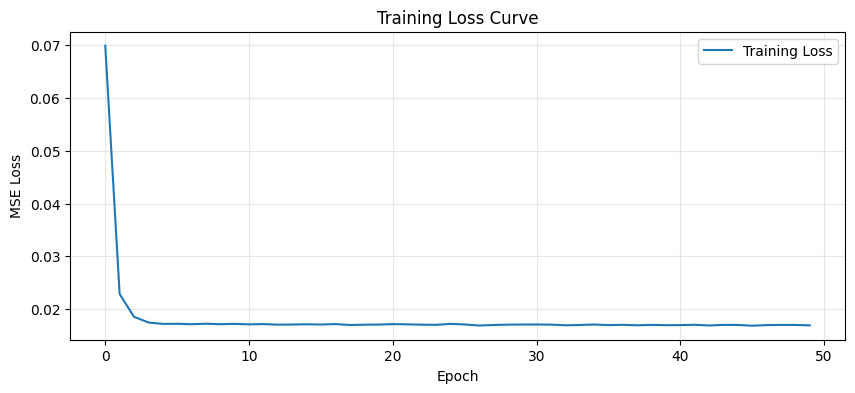


✅ 모델 저장 완료: attention_rnn_model.pth


In [ ]:
# ===== 모델 학습 =====

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 데이터를 PyTorch Tensor로 변환
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)

X_test_emerg_t = torch.FloatTensor(X_test_emerg).to(device)
y_test_emerg_t = torch.FloatTensor(y_test_emerg).to(device)

X_test_death_t = torch.FloatTensor(X_test_death).to(device)
y_test_death_t = torch.FloatTensor(y_test_death).to(device)

# DataLoader 생성
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print("=" * 60)
print("학습 시작")
print("=" * 60)
print(f"학습 샘플: {len(X_train)}개")
print(f"배치 크기: 16")
print(f"에포크: 50")
print(f"옵티마이저: Adam (lr=0.001)")
print(f"손실함수: MSE")

# 손실함수 및 옵티마이저
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        # Forward
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # 10 에포크마다 출력
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

print("\n" + "=" * 60)
print("✅ 학습 완료!")
print("=" * 60)
print(f"최종 Loss: {train_losses[-1]:.6f}")

# 학습 곡선 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 모델 저장
torch.save(model.state_dict(), 'attention_rnn_model.pth')
print("\n✅ 모델 저장 완료: attention_rnn_model.pth")

1단계: MAE 오차 계산
평소 ADL MAE:
  평균: 0.0885
  표준편차: 0.0282
  최소: 0.0262
  최대: 0.2237

응급 ADL MAE:
  평균: 0.6554
  표준편차: 0.1081

사망전 ADL MAE:
  평균: 0.4487
  표준편차: 0.0556

1단계: z-score 이상 감지
평소 ADL 기준:
  평균(μ): 0.0885
  표준편차(σ): 0.0282
  임계값: z > 1.44 (상위 7.5%)

이상 감지 결과:
  평소 ADL:    126/1350 (9.3%) - False Positive
  응급 ADL:   1350/1350 (100.0%) - True Positive ✓
  사망전 ADL: 1350/1350 (100.0%) - True Positive ✓


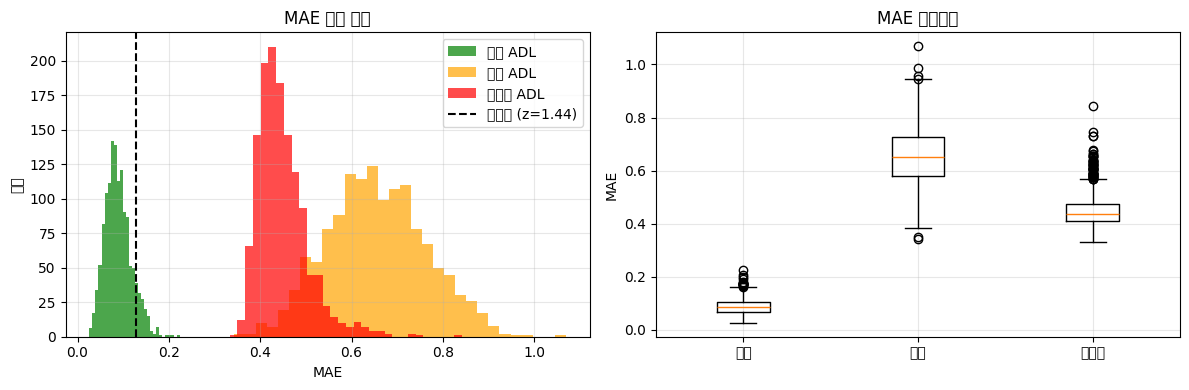


✅ 1단계 이상 감지 완료!


In [ ]:
# ===== 이상 감지 - 1단계: MAE + z-score =====

def calculate_mae(model, X, y):
    """
    MAE(Mean Absolute Error) 계산

    Returns:
        mae_per_sample: 각 샘플의 MAE (1차원 배열)
    """
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X).to(device)
        y_pred = model(X_t).cpu().numpy()

    # 샘플별 MAE 계산
    mae_per_sample = np.mean(np.abs(y_pred - y), axis=1)
    return mae_per_sample

print("=" * 60)
print("1단계: MAE 오차 계산")
print("=" * 60)

# 각 데이터셋의 MAE 계산
mae_train = calculate_mae(model, X_train, y_train)
mae_emerg = calculate_mae(model, X_test_emerg, y_test_emerg)
mae_death = calculate_mae(model, X_test_death, y_test_death)

print(f"평소 ADL MAE:")
print(f"  평균: {mae_train.mean():.4f}")
print(f"  표준편차: {mae_train.std():.4f}")
print(f"  최소: {mae_train.min():.4f}")
print(f"  최대: {mae_train.max():.4f}")

print(f"\n응급 ADL MAE:")
print(f"  평균: {mae_emerg.mean():.4f}")
print(f"  표준편차: {mae_emerg.std():.4f}")

print(f"\n사망전 ADL MAE:")
print(f"  평균: {mae_death.mean():.4f}")
print(f"  표준편차: {mae_death.std():.4f}")

# z-score 이상 감지
print("\n" + "=" * 60)
print("1단계: z-score 이상 감지")
print("=" * 60)

# 평소 ADL 기준으로 통계 계산
mu = mae_train.mean()
sigma = mae_train.std()

# 임계값 설정 (논문: p=0.925, z=1.44)
p_value = 0.925
z_threshold = 1.44

print(f"평소 ADL 기준:")
print(f"  평균(μ): {mu:.4f}")
print(f"  표준편차(σ): {sigma:.4f}")
print(f"  임계값: z > {z_threshold} (상위 {(1-p_value)*100:.1f}%)")

# 이상 판정
def detect_anomaly_zscore(mae_scores, mu, sigma, threshold=1.44):
    z_scores = (mae_scores - mu) / sigma
    anomalies = z_scores > threshold
    return anomalies, z_scores

anomaly_train, z_train = detect_anomaly_zscore(mae_train, mu, sigma, z_threshold)
anomaly_emerg, z_emerg = detect_anomaly_zscore(mae_emerg, mu, sigma, z_threshold)
anomaly_death, z_death = detect_anomaly_zscore(mae_death, mu, sigma, z_threshold)

print(f"\n이상 감지 결과:")
print(f"  평소 ADL:   {anomaly_train.sum():4d}/{len(anomaly_train)} ({anomaly_train.mean()*100:.1f}%) - False Positive")
print(f"  응급 ADL:   {anomaly_emerg.sum():4d}/{len(anomaly_emerg)} ({anomaly_emerg.mean()*100:.1f}%) - True Positive ✓")
print(f"  사망전 ADL: {anomaly_death.sum():4d}/{len(anomaly_death)} ({anomaly_death.mean()*100:.1f}%) - True Positive ✓")

# MAE 분포 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(mae_train, bins=30, alpha=0.7, label='평소 ADL', color='green')
plt.hist(mae_emerg, bins=30, alpha=0.7, label='응급 ADL', color='orange')
plt.hist(mae_death, bins=30, alpha=0.7, label='사망전 ADL', color='red')
plt.axvline(mu + z_threshold * sigma, color='black', linestyle='--', label=f'임계값 (z={z_threshold})')
plt.xlabel('MAE')
plt.ylabel('빈도')
plt.title('MAE 분포 비교')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([mae_train, mae_emerg, mae_death], labels=['평소', '응급', '사망전'])
plt.ylabel('MAE')
plt.title('MAE 박스플롯')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 1단계 이상 감지 완료!")

In [ ]:
# ===== 새로운 테스트 데이터 평가 =====

print("=" * 60)
print("새로운 테스트 데이터 로드 (SET7, SET8)")
print("=" * 60)

# SET7, SET8 데이터 로드
df_test_normal = pd.concat([
    pd.read_csv('/content/1779723284589_SET7_평소ADL_5명_60일.csv', encoding='utf-8-sig'),
    pd.read_csv('/content/1779723284589_SET8_평소ADL_5명_60일.csv', encoding='utf-8-sig')
], ignore_index=True)

df_test_emergency = pd.concat([
    pd.read_csv('/content/1779723284588_SET7_응급ADL_5명_60일.csv', encoding='utf-8-sig'),
    pd.read_csv('/content/1779723284588_SET8_응급ADL_5명_60일.csv', encoding='utf-8-sig')
], ignore_index=True)

df_test_death = pd.concat([
    pd.read_csv('/content/1779723284588_SET7_사망전ADL_5명_60일.csv', encoding='utf-8-sig'),
    pd.read_csv('/content/1779723284588_SET8_사망전ADL_5명_60일.csv', encoding='utf-8-sig')
], ignore_index=True)

print(f"✅ 평소 ADL:   {df_test_normal.shape}")
print(f"✅ 응급 ADL:   {df_test_emergency.shape}")
print(f"✅ 사망전 ADL: {df_test_death.shape}")
print(f"\n총 테스트 환자: {df_test_normal['care_recipient_id'].nunique()}명")

# 전처리
print("\n" + "=" * 60)
print("전처리 (hex → 16개 특징)")
print("=" * 60)

# 이미 정의된 preprocessor 사용
df_features_test_normal = preprocessor.process_dataframe(df_test_normal)
df_features_test_emergency = preprocessor.process_dataframe(df_test_emergency)
df_features_test_death = preprocessor.process_dataframe(df_test_death)

print(f"✅ 평소 전처리: {df_features_test_normal.shape}")
print(f"✅ 응급 전처리: {df_features_test_emergency.shape}")
print(f"✅ 사망 전처리: {df_features_test_death.shape}")

# 라벨 추가
df_features_test_normal['label'] = 0
df_features_test_emergency['label'] = 1
df_features_test_death['label'] = 2

# 정규화 (저장된 scaler 사용)
print("\n" + "=" * 60)
print("정규화 (학습 때 저장한 scaler 사용)")
print("=" * 60)

df_test_normal_scaled = preprocessor.transform(df_features_test_normal)
df_test_emergency_scaled = preprocessor.transform(df_features_test_emergency)
df_test_death_scaled = preprocessor.transform(df_features_test_death)

print(f"✅ 정규화 완료")

# 슬라이딩 윈도우 생성
print("\n" + "=" * 60)
print("슬라이딩 윈도우 생성 (15일)")
print("=" * 60)

X_test_normal, y_test_normal, meta_test_normal = create_sliding_windows(df_test_normal_scaled, window_size=15)
X_test_emerg_new, y_test_emerg_new, meta_test_emerg_new = create_sliding_windows(df_test_emergency_scaled, window_size=15)
X_test_death_new, y_test_death_new, meta_test_death_new = create_sliding_windows(df_test_death_scaled, window_size=15)

print(f"✅ 평소:   X={X_test_normal.shape}, y={y_test_normal.shape}")
print(f"✅ 응급:   X={X_test_emerg_new.shape}, y={y_test_emerg_new.shape}")
print(f"✅ 사망전: X={X_test_death_new.shape}, y={y_test_death_new.shape}")

print("\n🎯 진짜 테스트 데이터 준비 완료!")

새로운 테스트 데이터 로드 (SET7, SET8)


FileNotFoundError: [Errno 2] No such file or directory: '/content/1779723284589_SET7_평소ADL_5명_60일.csv'

In [ ]:
# ===== 새로운 테스트 데이터 로드 (SET7, SET8) =====

print("=" * 60)
print("테스트 데이터 로드")
print("=" * 60)

# SET7, SET8 데이터 로드
df_test_normal = pd.concat([
    pd.read_csv('/content/SET7_평소ADL_5명_60일.csv', encoding='utf-8-sig'),
    pd.read_csv('/content/SET8_평소ADL_5명_60일.csv', encoding='utf-8-sig')
], ignore_index=True)

df_test_emergency = pd.concat([
    pd.read_csv('/content/SET7_응급ADL_5명_60일.csv', encoding='utf-8-sig'),
    pd.read_csv('/content/SET8_응급ADL_5명_60일.csv', encoding='utf-8-sig')
], ignore_index=True)

df_test_death = pd.concat([
    pd.read_csv('/content/SET7_사망전ADL_5명_60일.csv', encoding='utf-8-sig'),
    pd.read_csv('/content/SET8_사망전ADL_5명_60일.csv', encoding='utf-8-sig')
], ignore_index=True)

print(f"✅ 평소 ADL:   {df_test_normal.shape}")
print(f"✅ 응급 ADL:   {df_test_emergency.shape}")
print(f"✅ 사망전 ADL: {df_test_death.shape}")
print(f"총 테스트 환자: {df_test_normal['care_recipient_id'].nunique()}명")

# 전처리
print("\n" + "=" * 60)
print("전처리 (hex → 16개 특징)")
print("=" * 60)

df_features_test_normal = preprocessor.process_dataframe(df_test_normal)
df_features_test_emergency = preprocessor.process_dataframe(df_test_emergency)
df_features_test_death = preprocessor.process_dataframe(df_test_death)

print(f"✅ 평소 전처리: {df_features_test_normal.shape}")
print(f"✅ 응급 전처리: {df_features_test_emergency.shape}")
print(f"✅ 사망 전처리: {df_features_test_death.shape}")

# 라벨 추가
df_features_test_normal['label'] = 0
df_features_test_emergency['label'] = 1
df_features_test_death['label'] = 2

# 정규화 (학습 때 저장한 scaler 사용!)
print("\n" + "=" * 60)
print("정규화 (학습 때 저장한 scaler 사용)")
print("=" * 60)

df_test_normal_scaled = preprocessor.transform(df_features_test_normal)
df_test_emergency_scaled = preprocessor.transform(df_features_test_emergency)
df_test_death_scaled = preprocessor.transform(df_features_test_death)

print(f"✅ 정규화 완료")

# 슬라이딩 윈도우 생성
print("\n" + "=" * 60)
print("슬라이딩 윈도우 생성 (15일)")
print("=" * 60)

X_test_normal, y_test_normal, meta_test_normal = create_sliding_windows(df_test_normal_scaled, window_size=15)
X_test_emerg_new, y_test_emerg_new, meta_test_emerg_new = create_sliding_windows(df_test_emergency_scaled, window_size=15)
X_test_death_new, y_test_death_new, meta_test_death_new = create_sliding_windows(df_test_death_scaled, window_size=15)

print(f"✅ 평소:   X={X_test_normal.shape}, y={y_test_normal.shape}")
print(f"✅ 응급:   X={X_test_emerg_new.shape}, y={y_test_emerg_new.shape}")
print(f"✅ 사망전: X={X_test_death_new.shape}, y={y_test_death_new.shape}")

print("\n" + "=" * 60)
print("🎯 진짜 테스트 데이터 준비 완료!")
print("=" * 60)
print("이 데이터는 학습에 전혀 사용되지 않은 완전히 새로운 환자들입니다.")

테스트 데이터 로드
✅ 평소 ADL:   (600, 118)
✅ 응급 ADL:   (600, 118)
✅ 사망전 ADL: (600, 114)
총 테스트 환자: 10명

전처리 (hex → 16개 특징)
✅ 평소 전처리: (600, 18)
✅ 응급 전처리: (600, 18)
✅ 사망 전처리: (600, 18)

정규화 (학습 때 저장한 scaler 사용)
✅ 정규화 완료

슬라이딩 윈도우 생성 (15일)
✅ 평소:   X=(450, 15, 16), y=(450, 16)
✅ 응급:   X=(450, 15, 16), y=(450, 16)
✅ 사망전: X=(450, 15, 16), y=(450, 16)

🎯 진짜 테스트 데이터 준비 완료!
이 데이터는 학습에 전혀 사용되지 않은 완전히 새로운 환자들입니다.


학습된 모델로 예측 (Unseen Data)
평소 ADL MAE:
  평균: 0.0868
  표준편차: 0.0294

응급 ADL MAE:
  평균: 0.6568
  표준편차: 0.1126

사망전 ADL MAE:
  평균: 0.4469
  표준편차: 0.0547

이상 감지 (학습 데이터 기준 μ, σ 사용)
학습 기준: μ=0.0885, σ=0.0282, z>1.44

이상 감지 결과 (진짜 테스트):
  평소 ADL:     31/450 (6.9%) - False Positive
  응급 ADL:    450/450 (100.0%) - True Positive
  사망전 ADL:  450/450 (100.0%) - True Positive

✅ 최종 성능 평가 (Unseen Data)
Precision (정밀도): 0.9667
Recall (재현율):    1.0000
F1 Score:          0.9831

Confusion Matrix:
                예측 정상  예측 이상
실제 정상           419        31
실제 이상             0       900

📊 해석:
  TN (정상→정상):  419 - 평소를 정상으로 올바르게 판정
  FP (정상→이상):   31 - 평소를 이상으로 오판 (오탐)
  FN (이상→정상):    0 - 응급/사망을 평소로 오판 (놓침!)
  TP (이상→이상):  900 - 응급/사망을 이상으로 올바르게 감지

🎯 핵심 지표:
  응급/사망 감지율: 100.0% (놓친 건 0건)
  오탐률: 6.9%


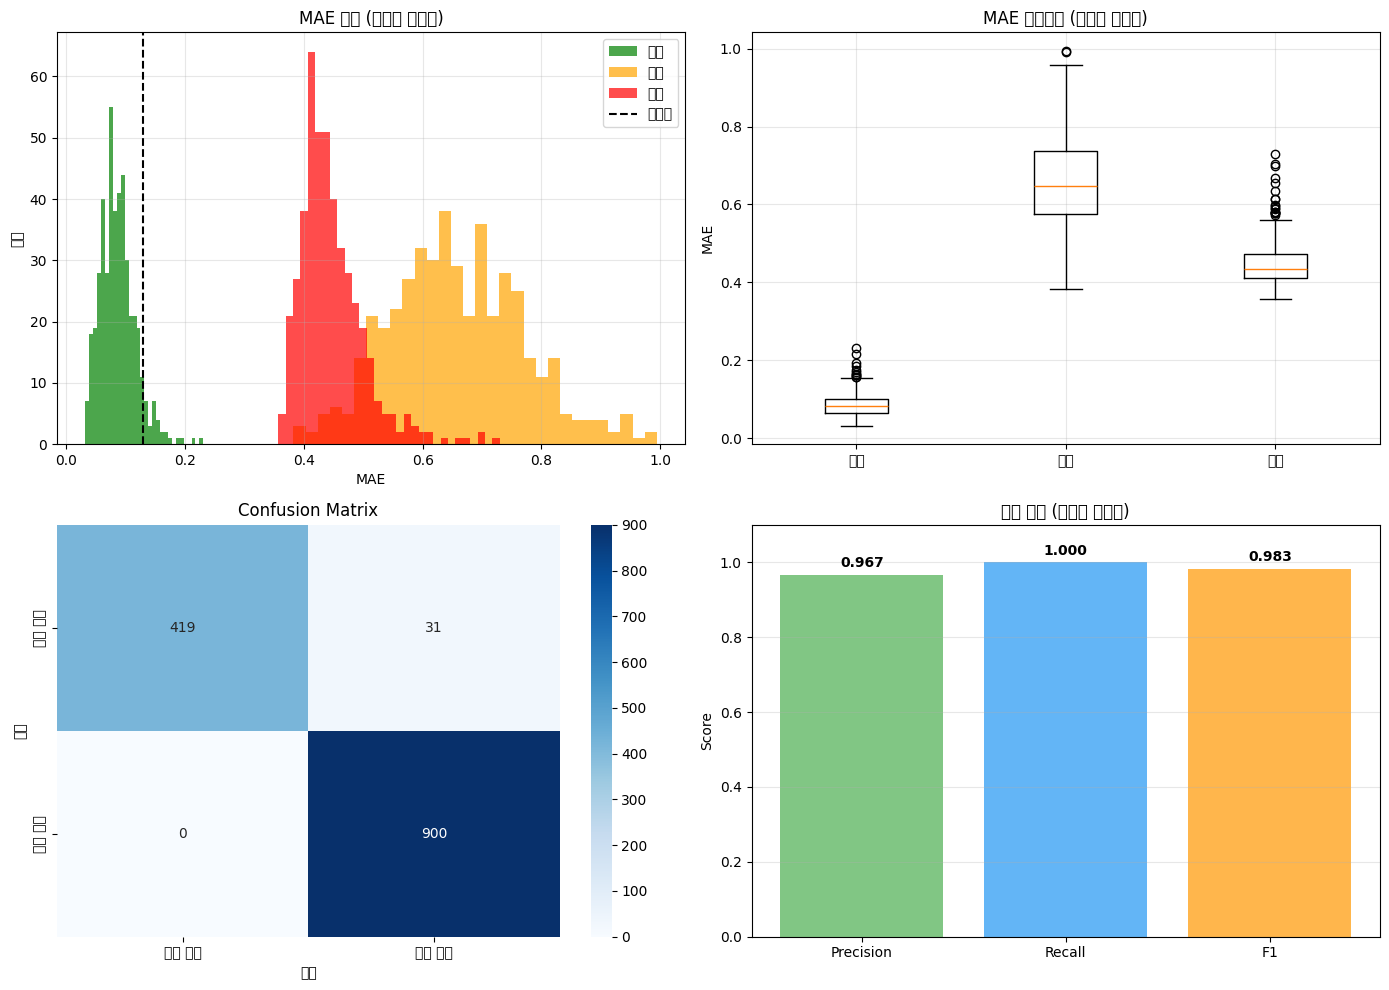


🎉 진짜 테스트 완료!


In [ ]:
# ===== 진짜 테스트 데이터로 성능 평가 =====

print("=" * 60)
print("학습된 모델로 예측 (Unseen Data)")
print("=" * 60)

# MAE 계산
mae_test_normal = calculate_mae(model, X_test_normal, y_test_normal)
mae_test_emerg = calculate_mae(model, X_test_emerg_new, y_test_emerg_new)
mae_test_death = calculate_mae(model, X_test_death_new, y_test_death_new)

print(f"평소 ADL MAE:")
print(f"  평균: {mae_test_normal.mean():.4f}")
print(f"  표준편차: {mae_test_normal.std():.4f}")

print(f"\n응급 ADL MAE:")
print(f"  평균: {mae_test_emerg.mean():.4f}")
print(f"  표준편차: {mae_test_emerg.std():.4f}")

print(f"\n사망전 ADL MAE:")
print(f"  평균: {mae_test_death.mean():.4f}")
print(f"  표준편차: {mae_test_death.std():.4f}")

# z-score 이상 감지 (학습 때 계산한 mu, sigma 사용)
print("\n" + "=" * 60)
print("이상 감지 (학습 데이터 기준 μ, σ 사용)")
print("=" * 60)
print(f"학습 기준: μ={mu:.4f}, σ={sigma:.4f}, z>1.44")

anomaly_test_normal, z_test_normal = detect_anomaly_zscore(mae_test_normal, mu, sigma, z_threshold)
anomaly_test_emerg, z_test_emerg = detect_anomaly_zscore(mae_test_emerg, mu, sigma, z_threshold)
anomaly_test_death, z_test_death = detect_anomaly_zscore(mae_test_death, mu, sigma, z_threshold)

print(f"\n이상 감지 결과 (진짜 테스트):")
print(f"  평소 ADL:   {anomaly_test_normal.sum():4d}/{len(anomaly_test_normal)} ({anomaly_test_normal.mean()*100:.1f}%) - False Positive")
print(f"  응급 ADL:   {anomaly_test_emerg.sum():4d}/{len(anomaly_test_emerg)} ({anomaly_test_emerg.mean()*100:.1f}%) - True Positive")
print(f"  사망전 ADL: {anomaly_test_death.sum():4d}/{len(anomaly_test_death)} ({anomaly_test_death.mean()*100:.1f}%) - True Positive")

# 성능 지표 계산
print("\n" + "=" * 60)
print("✅ 최종 성능 평가 (Unseen Data)")
print("=" * 60)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_true = np.concatenate([
    np.zeros(len(anomaly_test_normal)),
    np.ones(len(anomaly_test_emerg)),
    np.ones(len(anomaly_test_death))
])

y_pred = np.concatenate([
    anomaly_test_normal.astype(int),
    anomaly_test_emerg.astype(int),
    anomaly_test_death.astype(int)
])

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Precision (정밀도): {precision:.4f}")
print(f"Recall (재현율):    {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")

print(f"\nConfusion Matrix:")
print(f"                예측 정상  예측 이상")
print(f"실제 정상      {cm[0,0]:8d}  {cm[0,1]:8d}")
print(f"실제 이상      {cm[1,0]:8d}  {cm[1,1]:8d}")

print(f"\n📊 해석:")
print(f"  TN (정상→정상): {cm[0,0]:4d} - 평소를 정상으로 올바르게 판정")
print(f"  FP (정상→이상): {cm[0,1]:4d} - 평소를 이상으로 오판 (오탐)")
print(f"  FN (이상→정상): {cm[1,0]:4d} - 응급/사망을 평소로 오판 (놓침!)")
print(f"  TP (이상→이상): {cm[1,1]:4d} - 응급/사망을 이상으로 올바르게 감지")

print(f"\n🎯 핵심 지표:")
print(f"  응급/사망 감지율: {recall*100:.1f}% (놓친 건 {cm[1,0]}건)")
print(f"  오탐률: {(cm[0,1]/(cm[0,0]+cm[0,1]))*100:.1f}%")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MAE 분포
axes[0, 0].hist(mae_test_normal, bins=30, alpha=0.7, label='평소', color='green')
axes[0, 0].hist(mae_test_emerg, bins=30, alpha=0.7, label='응급', color='orange')
axes[0, 0].hist(mae_test_death, bins=30, alpha=0.7, label='사망', color='red')
axes[0, 0].axvline(mu + z_threshold * sigma, color='black', linestyle='--', label='임계값')
axes[0, 0].set_xlabel('MAE')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].set_title('MAE 분포 (테스트 데이터)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 박스플롯
axes[0, 1].boxplot([mae_test_normal, mae_test_emerg, mae_test_death],
                    labels=['평소', '응급', '사망'])
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('MAE 박스플롯 (테스트 데이터)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['정상 예측', '이상 예측'],
            yticklabels=['실제 정상', '실제 이상'])
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_ylabel('실제')
axes[1, 0].set_xlabel('예측')

# 4. 성능 지표
metrics = ['Precision', 'Recall', 'F1']
values = [precision, recall, f1]
colors = ['#4CAF50', '#2196F3', '#FF9800']
bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.7)
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('성능 지표 (테스트 데이터)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🎉 진짜 테스트 완료!")
print("=" * 60)